In [13]:
import os as os

import glob

from tqdm.auto import tqdm

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.animation as animation
from reproject import reproject_interp

from moviepy.video.io.ImageSequenceClip import ImageSequenceClip
import moviepy.video.fx as vfx

import sunpy
import sunpy.map
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from astropy.time import Time
from astropy.visualization import ImageNormalize, SqrtStretch


from sunpy.physics.differential_rotation import differential_rotate
from scipy import ndimage
from scipy.ndimage import gaussian_filter1d, median_filter, zoom
import sunpy.coordinates  # NOQA
from sunpy.net import Fido
from sunpy.net import attrs as a

import cmasher as cmr

import sys
sys.path.insert(0, '..')
from scripts.helpers import find_closest_hmi,find_closest_aia
from scripts.ribbon_map import RibbonMap as RM
from scripts.ribbon_map import RibbonCoords as RC
from scripts.ribbon_map import iris_reproject

import scienceplots
from sunpy.visualization.colormaps import color_tables as ct
plt.rcParams.update({'font.size': 14})
plt.style.use(['bright'])
# plt.rcParams['font.family'] = 'Atkinson Hyperlegible Next'
sdoaia1600 = ct.aia_color_table(1600*u.angstrom)
sji1400cm = ct.iris_sji_color_table('1400')

In [3]:
hmi_files=sorted(glob.glob("/home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/Across_time/HMI/*fits"))
aia_files=sorted(glob.glob("/home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/Across_time/AIA/*fits"))

In [1]:
time = '2026-02-03 14:03:02'
# time = clearest section of the flare. This time is used to find the closest HMI and AIA files to this time. Advise using a time that is in the middle of the flare to get the best results.
fn = '/home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/Across_time/HMI/hmi.m_45s.20260203_140300_TAI.2.magnetogram.fits'

HMI data mapping

2026-07-10 11:54:33 - sunpy - WARNING: SunpyUserWarning: Using 'time' assumes an Earth-based observer.


/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: Ru

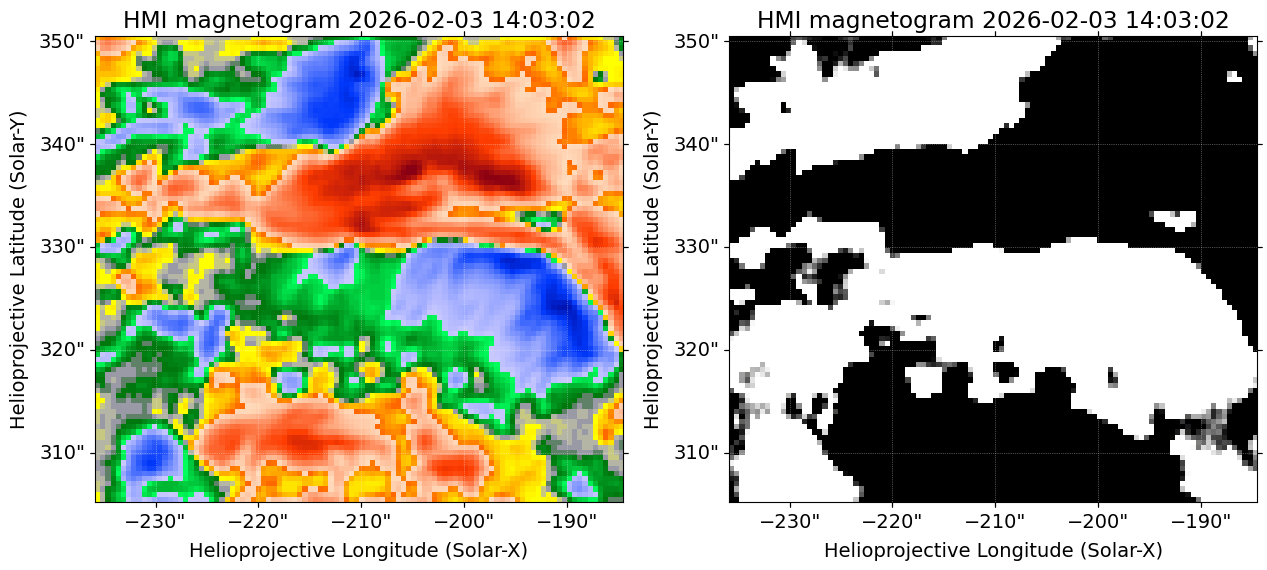

In [5]:
hmap = sunpy.map.Map(fn)
hmap = hmap.rotate(order=3)

xl, xr, yb, yt = -185, -236, 305, 350

xlims_world = [xl, xr]*u.arcsec 
ylims_world = [yb, yt]*u.arcsec

lb = SkyCoord(xlims_world[0],ylims_world[0],frame=hmap.coordinate_frame)
tr = SkyCoord(xlims_world[1],ylims_world[1],frame=hmap.coordinate_frame)

hmap = hmap.submap(lb, top_right=tr)
hmap = differential_rotate(hmap, time=time)


# --------------- Plot ---------------
fig = plt.figure(figsize=(15,8))

ax = fig.add_subplot(121, projection=hmap)
hmap.plot(axes=ax, cmap="hmimag", norm=None, vmin=-1500.0, vmax=1500.0)

ax = fig.add_subplot(122, projection=hmap)
hmap.plot(axes=ax, cmap=cmr.neutral, norm=None, vmin=-10.0, vmax=10.0)

PIL selecting

/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


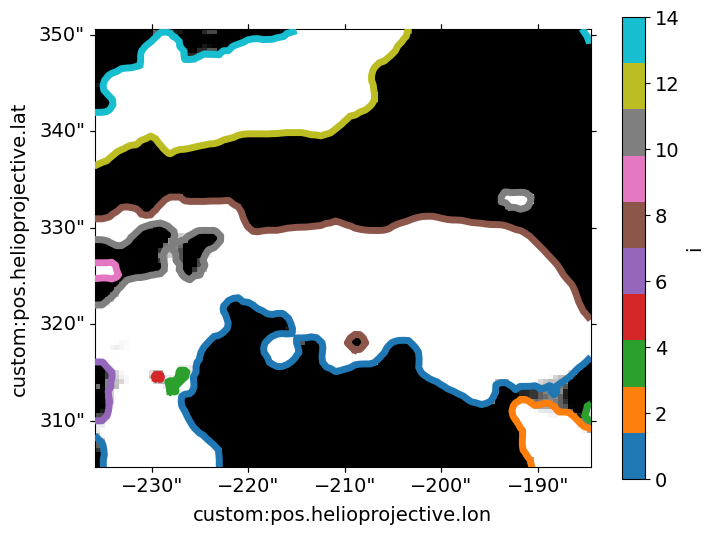

In [6]:
smoothed = median_filter(hmap.data, size=4) 
smooth_map = sunpy.map.Map(smoothed, hmap.meta)

hmi_PIL = smooth_map.find_contours(0 * u.G)
ihmax = np.argmax([h.shape[0] for h in hmi_PIL])

# pil = hmi_PIL[ihmax]
pil = hmi_PIL[9]

norm=mcolors.Normalize(vmin=0.0, vmax=len(hmi_PIL)-1)
cmap =cm.tab10

fig, ax = plt.subplots(figsize=(8,6), subplot_kw={'projection': smooth_map})
im = ax.imshow(smoothed, origin='lower', cmap="Greys_r", vmin=-10.0, vmax=10.0)

for i in range(len(hmi_PIL)):
    ax.plot_coord(hmi_PIL[i], color=cmap(norm(i)), linewidth=5)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required but unused
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("i")

HMI conturing and PIL plotting

/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: Ru

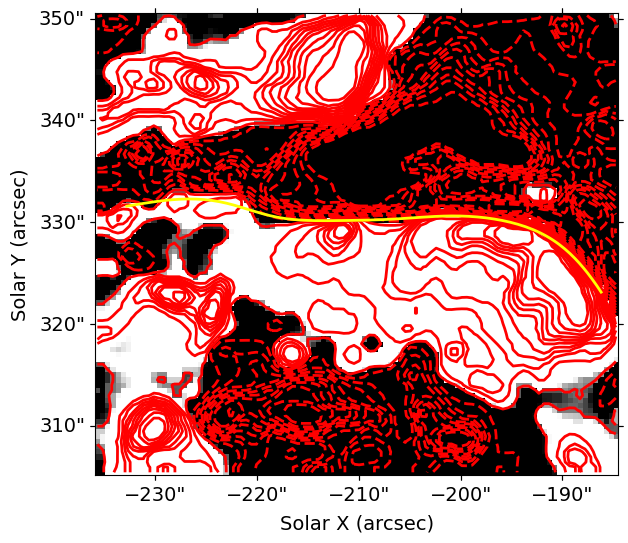

In [7]:
smoothed = median_filter(hmap.data, size=4) 
smooth_map = sunpy.map.Map(smoothed, hmap.meta)

hmi_PIL = smooth_map.find_contours(0 * u.G)
ihmax = np.argmax([h.shape[0] for h in hmi_PIL])

# pil = hmi_PIL[ihmax]
pil = hmi_PIL[8]

tx_smooth = gaussian_filter1d(pil.Tx.arcsec, sigma=10)
ty_smooth = gaussian_filter1d(pil.Ty.arcsec, sigma=10)

hmi_PIL_smooth = SkyCoord(tx_smooth * u.arcsec, ty_smooth * u.arcsec,
                          frame=smooth_map.coordinate_frame)

hmi_arcsec = np.column_stack([hmi_PIL_smooth.Tx.arcsec, hmi_PIL_smooth.Ty.arcsec])
np.savetxt('auxiliary_data/hmi_pil_world_median.csv', hmi_arcsec, delimiter=',', header='Tx_arcsec,Ty_arcsec')


# --------------- Plot ---------------
fig, ax = plt.subplots(figsize=(8,6), subplot_kw={'projection': smooth_map})
im = ax.imshow(smoothed, origin='lower', cmap=cmr.neutral, vmin=-10.0, vmax=10.0)

plt.contour(smoothed, levels=np.linspace(-1000, 1000, 21), colors='red', linewidths=2)
ax.plot_coord(hmi_PIL_smooth,color='yellow', linewidth=2)

ax.set_ylabel('Solar Y (arcsec)')
ax.set_xlabel('Solar X (arcsec)')

HMI and PIL plotting and smoothing

/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: Ru

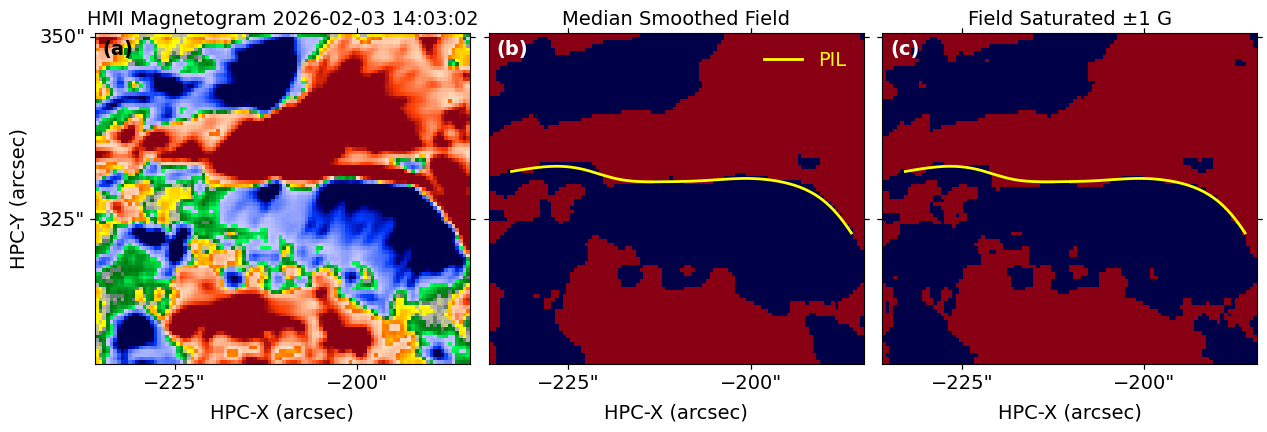

In [8]:
fig = plt.figure(figsize=(15, 8))


ax = fig.add_subplot(131, projection=hmap)
hmap.plot(axes=ax, cmap="hmimag", norm=None, vmin=-500.0, vmax=500.0)
ax.set_xlabel('HPC-X (arcsec)')
ax.set_ylabel('HPC-Y (arcsec)')
ax.set_title(f'HMI Magnetogram {hmap.date.strftime("%Y-%m-%d %H:%M:%S")}', fontsize=14)
ax.grid(False)
ax.coords[0].set_ticks(spacing=25 * u.arcsec)   
ax.coords[1].set_ticks(spacing=25 * u.arcsec)  
ax.text(0.02, 0.98, '(a)', transform=ax.transAxes, fontsize=14,
        va='top', ha='left', color='black', fontweight='bold')

ax = fig.add_subplot(132, projection=smooth_map)
im = ax.imshow(smoothed, origin='lower', cmap="hmimag", vmin=-.001, vmax=0.001)
ax.coords[1].set_ticklabel_visible(False)
ax.coords[1].set_axislabel('')
ax.set_xlabel('HPC-X (arcsec)')
ax.set_title('Median Smoothed Field', fontsize=14)
ax.plot_coord(hmi_PIL_smooth, color='yellow', linewidth=2, label='PIL')
ax.legend(loc='upper right', frameon=False, labelcolor='yellow')
ax.coords[0].set_ticks(spacing=25 * u.arcsec)  
ax.coords[1].set_ticks(spacing=25 * u.arcsec)  
ax.text(0.02, 0.98, '(b)', transform=ax.transAxes, fontsize=14,
        va='top', ha='left', color='white', fontweight='bold')

ax = fig.add_subplot(133, projection=hmap)
hmap.plot(axes=ax, cmap="hmimag", norm=None, vmin=-.001, vmax=0.001)
ax.coords[1].set_ticklabel_visible(False)
ax.coords[1].set_axislabel('')
ax.set_xlabel('HPC-X (arcsec)')
ax.set_title('Field Saturated ±1 G', fontsize=14)
ax.plot_coord(hmi_PIL_smooth, color='yellow', linewidth=2)
ax.grid(False)
ax.coords[0].set_ticks(spacing=25 * u.arcsec)   
ax.coords[1].set_ticks(spacing=25 * u.arcsec)  
ax.text(0.02, 0.98, '(c)', transform=ax.transAxes, fontsize=14,
        va='top', ha='left', color='white', fontweight='bold')

plt.subplots_adjust(wspace=0.05)
plt.savefig('figures/hmi_pil_smoothing.pdf', dpi=300, bbox_inches='tight')


Gathering all the files and aligning them

In [9]:
base_file = aia_files[0]
base_map = sunpy.map.Map(base_file)
base_time = base_map.date

xl, xr, yb, yt = -140, -280, 260, 380 # larger FOV to capture more of the ribbons
xlims_world = [xl, xr]*u.arcsec #small
ylims_world = [yb, yt]*u.arcsec

lb = SkyCoord(xlims_world[0],ylims_world[0],frame=base_map.coordinate_frame)
tr = SkyCoord(xlims_world[1],ylims_world[1],frame=base_map.coordinate_frame)
pil_world = SkyCoord(hmi_arcsec[:,0]*u.arcsec, hmi_arcsec[:,1]*u.arcsec, frame=base_map.coordinate_frame)


In [3]:
# This may take a while to run, as it processes each AIA file in the sequence. The output will be a series of images saved in the specified directory, which are later combined into a video.
for file_index, file in enumerate(tqdm(aia_files)):
     ref_map = sunpy.map.Map(file)
     rotated_map = differential_rotate(ref_map, time=time)


     amap = rotated_map.submap(lb, top_right=tr)

     separations = pil_world[1:].separation(pil_world[:-1]).to(u.arcsec)

     arcsec = np.concatenate([[0], np.cumsum(separations.value)]) * u.arcsec
     intensity = sunpy.map.sample_at_coords(amap, pil_world)


     rmap,xarc,yarc = RM(amap, pil_world, xoffsets=[-45, 45], diff_rotate=True, ref_map=base_map)
     slice_coords, cross_arcsec = RC(amap, pil_world, xoffsets=[-45, 45], diff_rotate=True, ref_map=base_map)


     fig = plt.figure(figsize=(7, 7))
     ax = plt.subplot(projection=amap)
     amap.plot(axes=ax,vmax=np.percentile(amap.data, 99))
     ax.grid(False)
     ax.set_title(f' AIA 1600 Å {ref_map.date.strftime("%Y-%m-%d %H:%M:%S")}', fontsize=16)
     ax.set_xlabel('HPC-X (arcsec)')
     ax.set_ylabel('HPC-Y (arcsec)')

     ax.plot_coord(pil_world, linewidth=3, color='red',alpha=0.8)

     center_idx = np.argmin(np.abs(cross_arcsec))  # index where offset ≈ 0
     start = center_idx % 10                        # shift so center_idx lands in the sample
     slices = slice_coords[start::10]
     mid = (center_idx - start) // 10              # index of offset=0 within `slices`

     for i, sc in enumerate(slices):
            t = abs(i - mid) / max(mid, len(slices) - 1 - mid)
            lw = 1.4 - 0.8 * t
            alpha = 0.85 - 0.45 * t
            if i <= mid:
                frac = (mid - i) / max(mid, 1)
                color = (1.0, 0.55 * frac, 0.0)
            else:
                frac = (i - mid) / max(len(slices) - 1 - mid, 1)
                color = (1.0, frac, 0.0)
            ax.plot_coord(sc, linewidth=1.0, color=color, alpha=alpha)
     plt.savefig(f"/home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/Across_time/Figures/Sequence/ sequence_{file_index:03d}.png")
     plt.close(fig)

NameError: name 'tqdm' is not defined

Creating a movie out of all the files

In [15]:
def make_movie_with_moviepy(image_folder, output_folder, video_name, fps):
    os.makedirs(output_folder, exist_ok=True)
    

    full_output_path = os.path.join(output_folder, video_name)
    
    images = sorted([os.path.join(image_folder, img) for img in os.listdir(image_folder) if img.endswith(".png")])
    if not images:
        return
        
    clip = ImageSequenceClip(images, fps=fps)
    
    clip.write_videofile(full_output_path, codec='libx264')
    print(f"Success! Movie saved to: {full_output_path}")

make_movie_with_moviepy(
    image_folder='/home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/Across_time/Figures/Sequence', 
    output_folder='/home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/Across_time/Figures/Sequence',
    video_name='AIAPIL_across_time.mp4', 
    fps=10)

MoviePy - Building video /home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/Across_time/Figures/Sequence/AIAPIL_across_time.mp4.
MoviePy - Writing video /home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/Across_time/Figures/Sequence/AIAPIL_across_time.mp4



MoviePy - Done !
MoviePy - video ready /home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/Across_time/Figures/Sequence/AIAPIL_across_time.mp4
Success! Movie saved to: /home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/Across_time/Figures/Sequence/AIAPIL_across_time.mp4
